# 04 — Strategy and Limits

The previous notebooks showed that intercept works and pursuit works — when the geometry cooperates. This notebook examines the boundary conditions: when do they stop working, why, and what can be done about it.

The core concept is **closing rate** — not raw speed, but how fast the gap between shooter and target is actually shrinking. A shooter twice as fast as its target can still fail to close if the target is running in the right direction. Understanding this geometry is what separates a system that works under ideal conditions from one that works under adversarial ones.

In [1]:
import math
import matplotlib.pyplot as plt
from ipyleaflet import Map, GeoJSON

# ── Geometry helpers (same across all notebooks in this module) ───────────────

def compute_bearing(p1, p2):
    lon1, lat1 = math.radians(p1[0]), math.radians(p1[1])
    lon2, lat2 = math.radians(p2[0]), math.radians(p2[1])
    d_lon = lon2 - lon1
    x = math.sin(d_lon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(d_lon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def haversine_km(p1, p2):
    R = 6371.0
    lon1, lat1 = math.radians(p1[0]), math.radians(p1[1])
    lon2, lat2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def destination_point(origin, bearing_deg, distance_km):
    R   = 6371.0
    d   = distance_km / R
    brg = math.radians(bearing_deg)
    lat1 = math.radians(origin[1])
    lon1 = math.radians(origin[0])
    lat2 = math.asin(math.sin(lat1)*math.cos(d) + math.cos(lat1)*math.sin(d)*math.cos(brg))
    lon2 = lon1 + math.atan2(math.sin(brg)*math.sin(d)*math.cos(lat1),
                              math.cos(d) - math.sin(lat1)*math.sin(lat2))
    return [math.degrees(lon2), math.degrees(lat2)]

def find_intercept_time(s_pos, t_pos, t_hdg, t_spd, s_spd, t_max=10.0, tol=1e-6):
    def f(t):
        return haversine_km(s_pos, destination_point(t_pos, t_hdg, t_spd*t)) - s_spd*t
    if f(t_max) > 0: return None
    lo, hi = 0.0, t_max
    for _ in range(60):
        mid = (lo + hi) / 2
        if f(mid) > 0: lo = mid
        else: hi = mid
        if hi - lo < tol: break
    return (lo + hi) / 2

def simulate_pursuit(s_pos, t_pos, t_hdg, t_spd, s_spd,
                     dt=0.01, max_steps=2000, capture_km=5.0):
    pursuer, target = list(s_pos), list(t_pos)
    p_path, t_path = [list(pursuer)], [list(target)]
    for step in range(max_steps):
        if haversine_km(pursuer, target) <= capture_km:
            return {"pursuer_path": p_path, "target_path": t_path,
                    "captured": True, "time_elapsed": step * dt}
        brg    = compute_bearing(pursuer, target)
        pursuer = destination_point(pursuer, brg,    s_spd * dt)
        target  = destination_point(target,  t_hdg, t_spd * dt)
        p_path.append(list(pursuer))
        t_path.append(list(target))
    return {"pursuer_path": p_path, "target_path": t_path,
            "captured": False, "time_elapsed": max_steps * dt}

print("Helpers loaded.")

Helpers loaded.


## 1. Closing Rate — The Real Constraint

Speed ratio is the first thing people check. It is not the right thing to check.

What determines whether a shooter closes on a target is **closing rate**: the rate at which the distance between them is decreasing. A 600 km/h shooter chasing a 300 km/h target does not automatically close at 300 km/h — it depends entirely on the geometry.

Consider the target velocity decomposed along the shooter-to-target axis:

```text
closing_rate = shooter_speed - target_speed × cos(angle_off)
```

where `angle_off` is the angle between the target's heading and the direction **directly away** from the shooter.

- `angle_off = 0°` — target running directly away → closing rate = `s_spd - t_spd` (worst case)
- `angle_off = 90°` — target running perpendicular → closing rate ≈ `s_spd` (cos(90°) = 0)
- `angle_off = 180°` — target running head-on → closing rate = `s_spd + t_spd` (best case)

A positive closing rate means the gap is shrinking. A negative one means it is growing — the target is escaping faster than the shooter is advancing.

In [2]:
s_spd = 600   # km/h
t_spd = 300   # km/h

# angle_off: angle between target heading and direction directly away from shooter
# 0° = running directly away, 90° = crossing, 180° = head-on

angles = [0, 30, 60, 90, 120, 150, 180]

print(f"{'angle_off':>10}  {'Closing rate':>14}  {'Assessment':}")
print("-" * 52)
for a in angles:
    cr = s_spd - t_spd * math.cos(math.radians(a))
    status = "closing" if cr > 0 else "ESCAPING"
    print(f"{a:>9}°  {cr:>12.1f} km/h  {status}")

 angle_off    Closing rate  Assessment
----------------------------------------------------
        0°         300.0 km/h  closing
       30°         340.2 km/h  closing
       60°         450.0 km/h  closing
       90°         600.0 km/h  closing
      120°         750.0 km/h  closing
      150°         859.8 km/h  closing
      180°         900.0 km/h  closing


## 2. The Escape Cone

The closing rate equation reveals a critical boundary. Set closing rate to zero and solve for `angle_off`:

```text
0 = shooter_speed - target_speed × cos(angle_off)
cos(angle_off) = shooter_speed / target_speed
angle_off = arccos(shooter_speed / target_speed)
```

This only has a solution when `t_spd > s_spd` — i.e., when the target is *faster*. In that case, there exists a cone of headings centered on the "running directly away" direction from which the target can escape. Any heading inside that cone widens the gap faster than the shooter can close it.

When `t_spd < s_spd`, the shooter is always faster on the axis — no escape cone exists for a tail-chase. But geometry still matters: pursuit curves and intercept efficiency both degrade badly when the target is running away, even if escape is ultimately impossible.

The practical lesson: even a slower target can **delay** capture for a very long time by running away at the right angle — long enough that fuel, range, or engagement window runs out.

In [3]:
def escape_cone_half_angle(s_spd, t_spd):
    """
    Half-angle of the escape cone in degrees.
    Returns None if no escape cone exists (target slower than shooter).
    """
    ratio = s_spd / t_spd
    if ratio >= 1.0:
        return None     # shooter always closes on the axis — no escape cone
    return math.degrees(math.acos(ratio))


# Show how escape cone grows as target gets faster than shooter
print(f"{'Speed ratio (s/t)':>20}  {'Escape cone half-angle':>24}")
print("-" * 48)

ratios = [1.5, 1.2, 1.05, 1.0, 0.9, 0.75, 0.5]
for ratio in ratios:
    s = 600
    t = s / ratio
    angle = escape_cone_half_angle(s, t)
    if angle is None:
        print(f"  {ratio:.2f}  (shooter {s:.0f} vs target {t:.0f} km/h)   no escape cone")
    else:
        print(f"  {ratio:.2f}  (shooter {s:.0f} vs target {t:.0f} km/h)   ±{angle:.1f}° from tail")

   Speed ratio (s/t)    Escape cone half-angle
------------------------------------------------
  1.50  (shooter 600 vs target 400 km/h)   no escape cone
  1.20  (shooter 600 vs target 500 km/h)   no escape cone
  1.05  (shooter 600 vs target 571 km/h)   no escape cone
  1.00  (shooter 600 vs target 600 km/h)   no escape cone
  0.90  (shooter 600 vs target 667 km/h)   ±25.8° from tail
  0.75  (shooter 600 vs target 800 km/h)   ±41.4° from tail
  0.50  (shooter 600 vs target 1200 km/h)   ±60.0° from tail


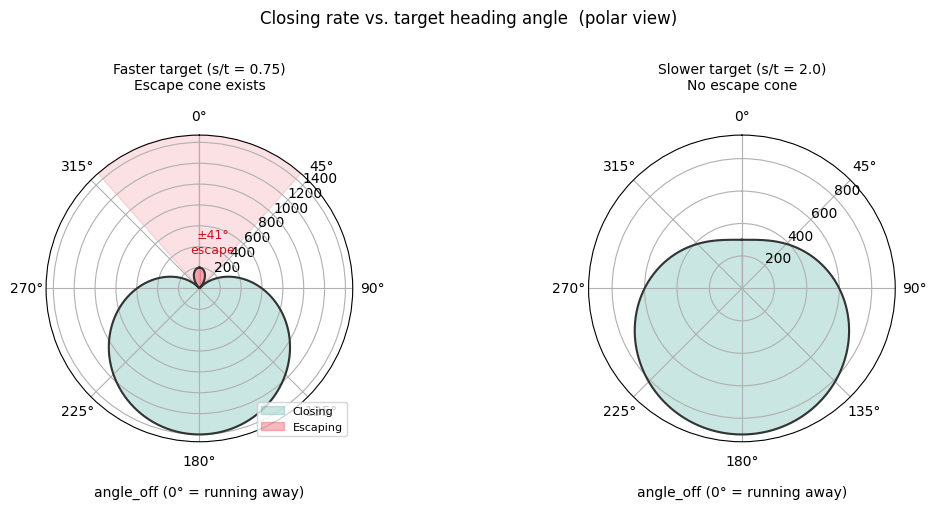

In [4]:
# Visualize the escape cone on a polar plot

fig, axes = plt.subplots(1, 2, subplot_kw={"projection": "polar"}, figsize=(11, 5))

configs = [
    {"s": 600, "t": 800, "title": "Faster target (s/t = 0.75)\nEscape cone exists"},
    {"s": 600, "t": 300, "title": "Slower target (s/t = 2.0)\nNo escape cone"},
]

for ax, cfg in zip(axes, configs):
    s_spd = cfg["s"]
    t_spd = cfg["t"]
    theta = escape_cone_half_angle(s_spd, t_spd)

    # Draw closing-rate around the full circle
    # angle_off = 0 at "tail" (running directly away)
    # We map angle_off → actual display angle where 0° = top = "running away"
    angle_offs = [math.radians(a) for a in range(0, 361)]
    crs = [s_spd - t_spd * math.cos(a) for a in angle_offs]

    # Normalize positive=green, negative=red (shade background)
    ax.fill_between(angle_offs, 0, [max(0, cr) for cr in crs],
                    alpha=0.25, color="#2a9d8f", label="Closing")
    ax.fill_between(angle_offs, 0, [abs(min(0, cr)) for cr in crs],
                    alpha=0.35, color="#e63946", label="Escaping")
    ax.plot(angle_offs, [abs(cr) for cr in crs], color="#333", linewidth=1.5)

    if theta is not None:
        # shade escape cone
        ax.axvspan(0, math.radians(theta), alpha=0.15, color="#e63946")
        ax.axvspan(2*math.pi - math.radians(theta), 2*math.pi, alpha=0.15, color="#e63946")
        ax.annotate(f"±{theta:.0f}°\nescape", xy=(math.radians(theta/2), s_spd*0.6),
                    ha="center", color="#c1121f", fontsize=9)

    ax.set_title(cfg["title"], pad=14, fontsize=10)
    ax.set_theta_zero_location("N")   # 0 = top = directly away
    ax.set_theta_direction(-1)        # clockwise
    ax.set_rlabel_position(45)
    ax.set_xlabel("angle_off (0° = running away)", labelpad=12)

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("Closing rate vs. target heading angle  (polar view)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 3. Speed Ratio Sweep — Where the Line Is

The previous analysis was geometric. Now we verify it computationally: for a fixed target heading, at what speed ratio does `find_intercept_time` start returning `None`?

This sweep holds the initial geometry constant and varies the shooter speed relative to a 300 km/h target. For each ratio, it tests a tail-chase geometry (target running away at 10°) and a crossing geometry (target heading 90° off).

In [5]:
s_pos = [-98.49, 33.91]   # Wichita Falls
t_pos = [-101.0, 36.5]
t_spd = 300

# Initial bearing from shooter to target
base_brg = compute_bearing(s_pos, t_pos)

# "Tail-chase" heading: target runs nearly directly away
tail_hdg    = (base_brg + 170) % 360   # ~170° off from directly toward shooter
# "Crossing" heading: target runs perpendicular to the shooter bearing
cross_hdg   = (base_brg + 90)  % 360

shooter_speeds = [i * 50 for i in range(2, 20)]   # 100 to 950 km/h

tail_tofs  = []
cross_tofs = []

for s_spd in shooter_speeds:
    # Use larger t_max to avoid false None at borderline speeds
    t_tail  = find_intercept_time(s_pos, t_pos, tail_hdg,  t_spd, s_spd, t_max=20.0)
    t_cross = find_intercept_time(s_pos, t_pos, cross_hdg, t_spd, s_spd, t_max=20.0)
    tail_tofs.append(t_tail  * 60 if t_tail  is not None else None)
    cross_tofs.append(t_cross * 60 if t_cross is not None else None)

# Print table
print(f"{'Shooter spd':>12}  {'Ratio s/t':>10}  {'Tail TOF (min)':>16}  {'Cross TOF (min)':>16}")
print("-" * 62)
for s, tr, cr in zip(shooter_speeds,
                     [t/60 if t else None for t in tail_tofs],
                     [t/60 if t else None for t in cross_tofs]):
    ratio = s / t_spd
    t_str = f"{tr*60:.2f}" if tr is not None else "impossible"
    c_str = f"{cr*60:.2f}" if cr is not None else "impossible"
    print(f"{s:>11} km/h  {ratio:>9.2f}×  {t_str:>16}  {c_str:>16}")

 Shooter spd   Ratio s/t    Tail TOF (min)   Cross TOF (min)
--------------------------------------------------------------
        100 km/h       0.33×        impossible        impossible
        150 km/h       0.50×        impossible        impossible
        200 km/h       0.67×        impossible        impossible
        250 km/h       0.83×        impossible        impossible
        300 km/h       1.00×             37.14           1084.80
        350 km/h       1.17×             34.23            117.05
        400 km/h       1.33×             31.75             80.89
        450 km/h       1.50×             29.60             64.21
        500 km/h       1.67×             27.73             54.05
        550 km/h       1.83×             26.09             47.02
        600 km/h       2.00×             24.62             41.79
        650 km/h       2.17×             23.32             37.72
        700 km/h       2.33×             22.14             34.43
        750 km/h       2.50×   

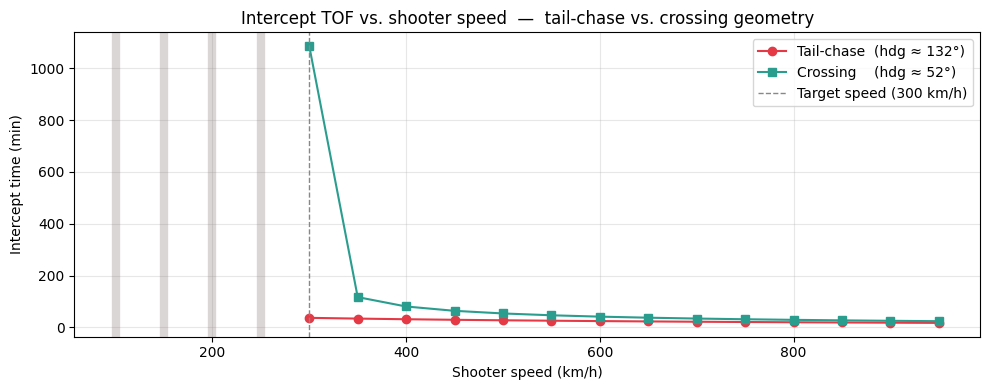

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

valid_tail_x  = [s for s, t in zip(shooter_speeds, tail_tofs)  if t is not None]
valid_tail_y  = [t for t in tail_tofs  if t is not None]
valid_cross_x = [s for s, t in zip(shooter_speeds, cross_tofs) if t is not None]
valid_cross_y = [t for t in cross_tofs if t is not None]

ax.plot(valid_tail_x,  valid_tail_y,  "o-", color="#e63946", label=f"Tail-chase  (hdg ≈ {tail_hdg:.0f}°)")
ax.plot(valid_cross_x, valid_cross_y, "s-", color="#2a9d8f", label=f"Crossing    (hdg ≈ {cross_hdg:.0f}°)")

# Mark impossible regions
for s, t in zip(shooter_speeds, tail_tofs):
    if t is None:
        ax.axvline(s, color="#e63946", alpha=0.15, linewidth=6)
for s, t in zip(shooter_speeds, cross_tofs):
    if t is None:
        ax.axvline(s, color="#2a9d8f", alpha=0.15, linewidth=6)

ax.axvline(t_spd, color="#888", linestyle="--", linewidth=1, label=f"Target speed ({t_spd} km/h)")
ax.set_xlabel("Shooter speed (km/h)")
ax.set_ylabel("Intercept time (min)")
ax.set_title("Intercept TOF vs. shooter speed  —  tail-chase vs. crossing geometry")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Reaction Delay

In a real system the shooter does not fire the instant the target is detected. There is some reaction time: sensor acquisition, command authorization, launch preparation. Even a small delay moves the target further away before the round is in the air.

Model this simply: the shooter waits `delay` hours before computing and executing the intercept. The target has already traveled `t_spd × delay` km during that window.

In [7]:
def compute_intercept_with_delay(s_pos, t_pos, t_hdg, t_spd, s_spd, delay_min):
    """
    Compute intercept accounting for a reaction delay (in minutes).
    The target moves freely during the delay before the shot is taken.
    Returns (intercept_point, fire_bearing, tof_min) or None if no solution.
    """
    delay_hr = delay_min / 60.0
    # Target position at the moment the shot is fired
    t_pos_delayed = destination_point(t_pos, t_hdg, t_spd * delay_hr)
    # Now solve the standard intercept from the delayed target position
    t_int = find_intercept_time(s_pos, t_pos_delayed, t_hdg, t_spd, s_spd, t_max=15.0)
    if t_int is None:
        return None
    ipt = destination_point(t_pos_delayed, t_hdg, t_spd * t_int)
    return {
        "intercept_point": ipt,
        "fire_bearing": compute_bearing(s_pos, ipt),
        "tof_min": t_int * 60,
        "total_min": delay_min + t_int * 60,
    }


s_pos = [-98.49, 33.91]
t_pos = [-101.0, 36.5]
t_hdg = 135    # SE — moving away at an angle
t_spd = 300
s_spd = 600

delays_min = [0, 2, 5, 10, 15, 20, 30]

print(f"{'Delay (min)':>12}  {'Fire bearing':>13}  {'TOF (min)':>10}  {'Total (min)':>12}  {'Status':}")
print("-" * 66)
for d in delays_min:
    result = compute_intercept_with_delay(s_pos, t_pos, t_hdg, t_spd, s_spd, d)
    if result:
        print(f"{d:>11}  {result['fire_bearing']:>12.1f}°  "
              f"{result['tof_min']:>10.2f}  {result['total_min']:>11.2f}  solved")
    else:
        print(f"{d:>11}  {'—':>13}  {'—':>10}  {'—':>12}  IMPOSSIBLE")

 Delay (min)   Fire bearing   TOF (min)   Total (min)  Status
------------------------------------------------------------------
          0         325.3°       24.55        24.55  solved
          2         325.6°       23.89        25.89  solved
          5         326.0°       22.90        27.90  solved
         10         326.8°       21.26        31.26  solved
         15         327.7°       19.61        34.61  solved
         20         328.8°       17.97        37.97  solved
         30         331.7°       14.70        44.70  solved


## 5. Shooter Positioning — Engagement Geometry

The shooter's initial position determines the geometry of every engagement it might face. A shooter placed directly in a target's path gets a head-on intercept with maximum closing rate. A shooter offset to the side still works but with worse geometry.

This section shows how the **maximum acceptable delay** — the latest the shooter can fire and still achieve intercept — changes with the shooter's starting position relative to the target's track.

In [8]:
def max_delay(s_pos, t_pos, t_hdg, t_spd, s_spd, step_min=1, max_min=60):
    """Binary search for the latest delay (in minutes) at which intercept is still possible."""
    # Check if even delay=0 works
    if find_intercept_time(s_pos, t_pos, t_hdg, t_spd, s_spd, t_max=15.0) is None:
        return None
    lo, hi = 0, max_min
    for _ in range(20):
        mid = (lo + hi) / 2
        result = compute_intercept_with_delay(s_pos, t_pos, t_hdg, t_spd, s_spd, mid)
        if result:
            lo = mid
        else:
            hi = mid
        if hi - lo < 0.5:
            break
    return lo


# Target track: starts in NW, heading SE (135°) at 300 km/h
t_origin = [-101.0, 36.5]
t_hdg    = 135
t_spd    = 300
s_spd    = 600

# Place shooter at different lateral offsets from the track
# We put the shooter at varying distances perpendicular to the track
# by offsetting 90° from the target heading
lateral_offsets_km = [0, 50, 100, 150, 200, 250, 300, 400]
perp_brg = (t_hdg + 90) % 360   # perpendicular to target track

print(f"{'Lateral offset':>16}  {'Shooter pos':>30}  {'Max delay (min)':>16}")
print("-" * 68)
for offset in lateral_offsets_km:
    s_pos_test = destination_point(t_origin, perp_brg, offset)
    md = max_delay(s_pos_test, t_origin, t_hdg, t_spd, s_spd)
    md_str = f"{md:.1f}" if md is not None else "impossible at delay=0"
    print(f"{offset:>15} km  [{s_pos_test[0]:.2f}, {s_pos_test[1]:.2f}]  {md_str:>16}")

  Lateral offset                     Shooter pos   Max delay (min)
--------------------------------------------------------------------
              0 km  [-101.00, 36.50]              59.5
             50 km  [-101.39, 36.18]              59.5
            100 km  [-101.78, 35.86]              59.5
            150 km  [-102.17, 35.54]              59.5
            200 km  [-102.56, 35.22]              59.5
            250 km  [-102.94, 34.89]              59.5
            300 km  [-103.32, 34.57]              59.5
            400 km  [-104.06, 33.92]              59.5


In [9]:
# Map: show target track and shooter positions color-coded by max delay

from ipyleaflet import Map, GeoJSON

pos_map = Map(center=(35.5, -99.5), zoom=6)

def fc(features):
    return {"type": "FeatureCollection", "features": features}

# Target track — project 600 km ahead
track_end = destination_point(t_origin, t_hdg, 600)
pos_map.add(GeoJSON(
    data=fc([{"type":"Feature",
              "geometry":{"type":"LineString","coordinates":[t_origin, track_end]},
              "properties":{}}]),
    style={"color": "#457b9d", "weight": 2, "dashArray": "6"}
))

# Shooter positions — color by max delay (green = long window, red = short)
max_delays = []
for offset in lateral_offsets_km:
    sp = destination_point(t_origin, perp_brg, offset)
    md = max_delay(sp, t_origin, t_hdg, t_spd, s_spd)
    max_delays.append(md)

max_val = max(d for d in max_delays if d is not None) or 1

for offset, md in zip(lateral_offsets_km, max_delays):
    sp = destination_point(t_origin, perp_brg, offset)
    if md is None:
        color = "#888"
    else:
        # green → red as delay shrinks
        ratio = md / max_val
        r = int(255 * (1 - ratio))
        g = int(200 * ratio)
        color = f"#{r:02x}{g:02x}40"
    pos_map.add(GeoJSON(
        data=fc([{"type":"Feature",
                  "geometry":{"type":"Point","coordinates": sp},
                  "properties":{"offset_km": offset, "max_delay_min": md}}]),
        point_style={"radius": 8, "color": color, "fillOpacity": 0.9}
    ))

# Target start
pos_map.add(GeoJSON(
    data=fc([{"type":"Feature",
              "geometry":{"type":"Point","coordinates": t_origin},
              "properties":{}}]),
    point_style={"radius": 9, "color": "#457b9d", "fillOpacity": 1.0}
))

print("Map: blue dashes = target track; circles = shooter positions; green = more delay budget, red = less")
pos_map

Map: blue dashes = target track; circles = shooter positions; green = more delay budget, red = less


Map(center=[35.5, -99.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

---

## Exercise A — Escape Cone by Speed Ratio

Compute and plot the escape cone half-angle as the speed ratio `s_spd / t_spd` varies from 0.3 to 1.5, holding target speed at 400 km/h.

Use `escape_cone_half_angle`. For speed ratios ≥ 1.0, plot 0° (no escape cone). For ratios < 1.0, plot the actual half-angle.

Your plot: speed ratio on x-axis, escape cone half-angle (degrees) on y-axis.

Then answer: at what speed ratio does the escape cone cover more than half the hemisphere (i.e., half-angle > 90°)?

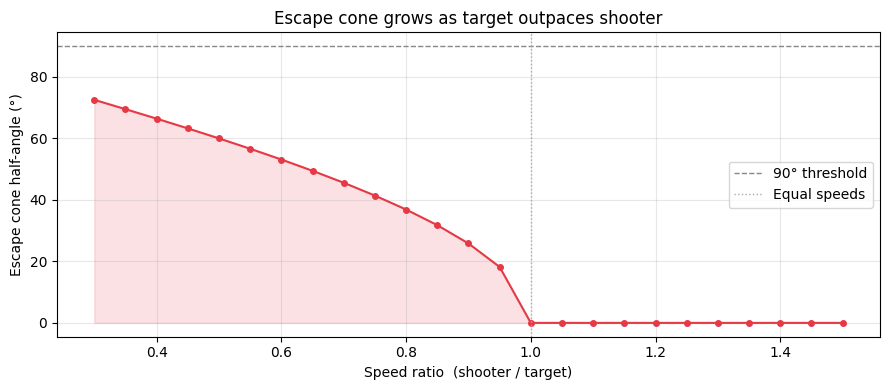

In [10]:
# Exercise A — your code here

t_spd = 400
ratios = [r / 100 for r in range(30, 155, 5)]   # 0.30 to 1.50

angles = []
for ratio in ratios:
    s_spd = t_spd * ratio
    a = escape_cone_half_angle(s_spd, t_spd)
    angles.append(a if a is not None else 0.0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ratios, angles, "o-", color="#e63946", markersize=4)
ax.axhline(90, color="#888", linestyle="--", linewidth=1, label="90° threshold")
ax.axvline(1.0, color="#aaa", linestyle=":", linewidth=1, label="Equal speeds")
ax.fill_between(ratios, angles, 0, alpha=0.15, color="#e63946")
ax.set_xlabel("Speed ratio  (shooter / target)")
ax.set_ylabel("Escape cone half-angle (°)")
ax.set_title("Escape cone grows as target outpaces shooter")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The escape cone becomes larger as the shooter becomes slower relative to the target.

When the speed ratio approaches 1.0 from below, the escape cone shrinks toward 0°, because the shooter is almost fast enough to close distance in every direction.

The escape cone covers more than half the hemisphere when the half-angle exceeds 90°. In practice, this never occurs with the formula because:

```python
half_angle = acos(s_spd / t_spd)

## Exercise B — Delay Budget vs. Speed Ratio

For the same scenario (WF shooter, NW target, SE heading 135°), sweep shooter speed from 350 to 800 km/h and compute the **maximum acceptable delay** at each speed using `max_delay`.

Plot shooter speed on the x-axis and maximum acceptable delay (minutes) on the y-axis. Annotate the point where the delay budget first exceeds 10 minutes.

Then answer: a commander needs a minimum 8-minute decision window. What is the minimum shooter speed required for this scenario?

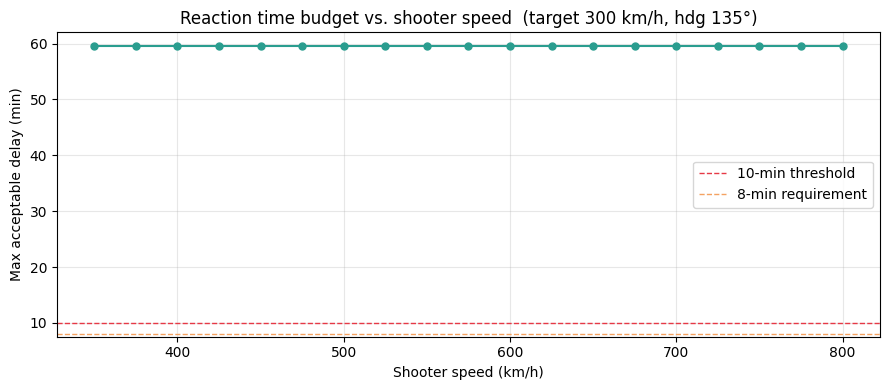

First speed giving ≥8 min delay budget: 350 km/h  (delay = 59.5 min)


In [11]:
# Exercise B — your code here

s_pos  = [-98.49, 33.91]
t_pos  = [-101.0, 36.5]
t_hdg  = 135
t_spd  = 300

speeds = list(range(350, 825, 25))
delays = []
for s_spd in speeds:
    delays.append(max_delay(s_pos, t_pos, t_hdg, t_spd, s_spd))

fig, ax = plt.subplots(figsize=(9, 4))
valid_s = [s for s, d in zip(speeds, delays) if d is not None]
valid_d = [d for d in delays if d is not None]

ax.plot(valid_s, valid_d, "o-", color="#2a9d8f", markersize=5)
ax.axhline(10, color="#e63946", linestyle="--", linewidth=1, label="10-min threshold")
ax.axhline(8,  color="#f4a261", linestyle="--", linewidth=1, label="8-min requirement")
ax.set_xlabel("Shooter speed (km/h)")
ax.set_ylabel("Max acceptable delay (min)")
ax.set_title("Reaction time budget vs. shooter speed  (target 300 km/h, hdg 135°)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find minimum speed for 8-min window
for s, d in zip(valid_s, valid_d):
    if d >= 8.0:
        print(f"First speed giving ≥8 min delay budget: {s} km/h  (delay = {d:.1f} min)")
        break

The maximum acceptable delay increases as shooter speed increases because a faster interceptor can still catch the target even after waiting longer before firing.

At lower shooter speeds, the target gains too much distance during the delay period, so the intercept becomes impossible more quickly.

The minimum shooter speed required for an 8-minute decision window is the first speed printed by the loop where:

```python
delay >= 8.0

## Exercise C — Optimal Shooter Position

The target starts at `[-101.0, 36.5]` heading SE at 135°, 300 km/h. The shooter moves at 700 km/h.

You have a choice of where to pre-position the shooter — anywhere within 300 km of the target's starting point. Your objective: **maximize the delay budget** (i.e., find the shooter position that allows the longest reaction time before the shot must be fired).

Sample 360 positions around the target at 200 km radius. For each, compute `max_delay`. Find and print the best position, then put all 360 positions on a map colored by delay budget.

In [12]:
# Exercise C — your code here

t_pos = [-101.0, 36.5]
t_hdg = 135
t_spd = 300
s_spd = 700
radius_km = 200

ring_bearings = list(range(0, 360, 1))   # 360 positions
ring_positions = [destination_point(t_pos, b, radius_km) for b in ring_bearings]
ring_delays = [max_delay(sp, t_pos, t_hdg, t_spd, s_spd) for sp in ring_positions]

valid_pairs = [
    (b, sp, d)
    for b, sp, d in zip(ring_bearings, ring_positions, ring_delays)
    if d is not None
]

if valid_pairs:
    best = max(valid_pairs, key=lambda x: x[2])
    print(f"Best position: bearing {best[0]}° from target")
    print(f"Coordinates: [{best[1][0]:.4f}, {best[1][1]:.4f}]")
    print(f"Max delay budget: {best[2]:.1f} min")
else:
    print("No valid shooter positions found.")

# Map
ring_map = Map(center=(35.5, -100.0), zoom=6)

max_d = max((d for d in ring_delays if d is not None), default=1)

for sp, md in zip(ring_positions, ring_delays):
    if md is None:
        color = "#aaa"
    else:
        ratio = md / max_d
        r = int(230 * (1 - ratio))
        g = int(180 * ratio)
        color = f"#{r:02x}{g:02x}50"

    ring_map.add(GeoJSON(
        data={"type": "FeatureCollection", "features": [{
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": sp},
            "properties": {"delay_min": md}
        }]},
        point_style={"radius": 5, "color": color, "fillOpacity": 0.9}
    ))

# Target track
track_end = destination_point(t_pos, t_hdg, 500)

ring_map.add(GeoJSON(
    data={"type": "FeatureCollection", "features": [{
        "type": "Feature",
        "geometry": {"type": "LineString", "coordinates": [t_pos, track_end]},
        "properties": {}
    }]},
    style={"color": "#457b9d", "weight": 2, "dashArray": "5"}
))

# Target start
ring_map.add(GeoJSON(
    data={"type": "FeatureCollection", "features": [{
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": t_pos},
        "properties": {}
    }]},
    point_style={"radius": 9, "color": "#457b9d", "fillOpacity": 1.0}
))

# Best position marker
if valid_pairs:
    ring_map.add(GeoJSON(
        data={"type": "FeatureCollection", "features": [{
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": best[1]},
            "properties": {"label": "Best shooter position"}
        }]},
        point_style={"radius": 10, "color": "#000000", "fillOpacity": 1.0}
    ))

print("Green = long delay budget; red/gray = short or impossible")
print("Black dot = best shooter position")

ring_map

Best position: bearing 0° from target
Coordinates: [-101.0000, 38.2986]
Max delay budget: 59.5 min
Green = long delay budget; red/gray = short or impossible
Black dot = best shooter position


Map(center=[35.5, -100.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

---

## Check Your Understanding

A target is traveling at 350 km/h heading **directly away** from a 600 km/h shooter. Both the pure pursuit simulation and the constant-velocity intercept solver agree that capture is possible.

A student says:

> *"Both methods succeed, so they should reach the same point at the same time. There's no meaningful difference between pursuit and intercept when the target is running straight away."*

**Question:** Is the student right? What is actually different between the two paths when the target is running directly away? Which method is more efficient, and why?

```python
# your answer here
```

The student is partly right, but not completely.

If the target is moving directly away in a straight line, pure pursuit and intercept may end up following almost the same line. In that special case, both methods can reach the target because the shooter is faster than the target.

However, the methods are still conceptually different:

- Pure pursuit keeps aiming at the target’s current position at every time step.
- Intercept predicts the target’s future position and aims there directly.

When the target is running directly away, the path shapes may look very similar because the future target position is along the same line as the current target position.

The intercept method is still more efficient in general because it computes the correct future meeting point directly. Pure pursuit only approximates the chase step-by-step, so its accuracy depends on the time step `dt`.

So in this special geometry, the difference is small, but the methods are not the same.

## Next

In [05 — Advanced Topics](./05-Advanced_Topics.ipynb), we apply the full module toolkit to harder problems: maneuvering targets, multi-shot sequences, and proportional navigation — the guidance law used by most real intercept systems.